In [1]:
# Google Colab / local setup
import os, sys, subprocess
from pathlib import Path
if "google.colab" in sys.modules:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    CODE_ROOT = Path("/content/drive/MyDrive/msc project/code")
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q", "--no-deps", "-e",
        str(CODE_ROOT), 'catboost==1.2.10', 'rapidfuzz==3.14.3',
    ])
else:
    CODE_ROOT = next(
        path for path in (Path.cwd(), *Path.cwd().parents)
        if (path / "pyproject.toml").exists()
    )
os.chdir(CODE_ROOT)
sys.path.insert(0, str(CODE_ROOT))
CODE = CODE_ROOT

# 02c — Sentiment sources and features

This notebook describes BTC news and direct-event features for January 2024–March 2026; it measures coverage and scorer differences, not trading profitability.
DeBERTa uses its own outputs and headline text, while LLM uses its own sentiment and structured metadata; no LLM metadata enters the DeBERTa arm.

## 1. Sources and scoring

The source contract below uses publication or crawler-visible timestamps, never later information.

| Source | Information | Available time |
|---|---|---|
| GDELT GKG via BigQuery | English approved-source headlines and tone | Crawler `seendate` |
| Federal Reserve / Truth Social | Direct-event text | Publication timestamp |
| FRED | Scheduled macro releases | Release time |
| Alternative.me | Fear & Greed | Daily publication |

The distinct timestamps determine when each input can first enter a feature.

DeBERTa (`mrm8488/deberta-v3-ft-financial-news-sentiment-analysis`) produces a −1 to +1 scalar; LLM (`deepseek-v4-flash:cloud`, prompt v4, temperature 0, batches ≤10) returns sentiment, relevance, impact and asset.
The exact prompt and JSON validation are implemented in `sentiment/score_llm.py`; scores are frozen for reproducibility.
Stories are deduplicated using a past-only 72-hour URL/title ledger, including ≥95% title similarity with matching numbers; features align to completed M15 bars.

In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from IPython.display import display

CODE_ROOT = Path.cwd().resolve()
if CODE_ROOT.name == "notebooks":
    CODE_ROOT = CODE_ROOT.parent
if str(CODE_ROOT) not in sys.path:
    sys.path.insert(0, str(CODE_ROOT))

from features.sentiment import (
    DIRECT_EVENT_HALFLIFE_H,
    MATCHED_SENTIMENT_FEATURES_BTC,
    build_direct_event_block,
    build_llm_full_features,
    build_matched_sentiment_features,
)
from sentiment.dedup import first_seen_only

ARTIFACT_DIR = CODE_ROOT / "notebooks" / "artifacts"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
RAW = CODE_ROOT / "sentiment" / "raw"
LOCKBOX = pd.Timestamp("2026-04-01", tz="UTC")
plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True, "grid.alpha": 0.2})
pd.set_option("display.max_colwidth", 86)

cfg = yaml.safe_load((CODE_ROOT / "configs" / "default.yaml").read_text())
price = pd.read_parquet(CODE_ROOT / cfg["instruments"]["btc"]["working_parquet"],
                        columns=["close"])
price.index = pd.to_datetime(price.index, utc=True)
price = price.loc[price.index < LOCKBOX]
bars = price.index

keys = ["seendate", "url", "title"]
classic_raw = pd.read_parquet(RAW / "scores_btc.parquet")
llm_raw = pd.read_parquet(RAW / "scores_llm_btc.parquet")
matched = classic_raw[[*keys, "sent"]].merge(
    llm_raw[[*keys, "llm_sent", "llm_relevance", "llm_impact", "llm_asset"]],
    on=keys, how="inner", validate="one_to_one").dropna(subset=["sent", "llm_sent"])
matched["seendate"] = pd.to_datetime(matched["seendate"], utc=True)
matched = first_seen_only(matched).sort_values("seendate")
matched = matched.loc[matched["seendate"] < LOCKBOX]

print(f"bars {len(bars):,} ({bars[0]:%Y-%m-%d} -> {bars[-1]:%Y-%m-%d}) | "
      f"matched unique stories {len(matched):,} | lockbox {LOCKBOX.date()} excluded")

bars 78,816 (2024-01-01 -> 2026-03-31) | matched unique stories 34,198 | lockbox 2026-04-01 excluded


## 2. Matched coverage

Scorers are matched on timestamp, URL and title before the same chronological deduplication.

In [3]:
from IPython.display import Markdown
coverage = pd.DataFrame([{
    "Stream": "GDELT headlines", "DeBERTa rows": len(classic_raw),
    "LLM rows": len(llm_raw), "Matched unique stories": len(matched),
    "First": matched["seendate"].min(), "Last": matched["seendate"].max(),
}])
display(Markdown('Method: Rows are intersected by timestamp, URL and title before causal deduplication.'))
display(coverage)
display(Markdown('The scorer comparison uses the same eligible stories.'))

r_all = matched["sent"].corr(matched["llm_sent"])
sign_all = float((np.sign(matched["sent"]) == np.sign(matched["llm_sent"])).mean())

examples = (matched.assign(gap=(matched["sent"] - matched["llm_sent"]).abs())
            .sort_values(["gap", "llm_relevance"], ascending=False).head(6)
            [["seendate", "title", "sent", "llm_sent", "llm_relevance", "llm_impact",
              "llm_asset"]]
            .rename(columns={"sent": "DeBERTa", "llm_sent": "LLM",
                             "llm_relevance": "Relevance", "llm_impact": "Impact",
                             "llm_asset": "Asset"}))
display(Markdown('Method: Examples are ranked by absolute disagreement on matched stories, without selecting trades.'))
display(examples.round({"DeBERTa": 2, "LLM": 2, "Relevance": 2}))
display(Markdown('Different asset interpretations can produce opposing sentiment scores.'))

Method: Rows are intersected by timestamp, URL and title before causal deduplication.

,Stream,DeBERTa rows,LLM rows,Matched unique stories,First,Last
0,GDELT headlines,34566,34566,34198,2024-01-01 00:00:00+00:00,2026-03-31 22:15:00+00:00


The scorer comparison uses the same eligible stories.

Method: Examples are ranked by absolute disagreement on matched stories, without selecting trades.

,seendate,title,DeBERTa,LLM,Relevance,Impact,Asset
23188,2025-05-26 13:00:00+00:00,'Cataclysmic' Fed U.S. Dollar 'Crisis' Warning Predicted To Spark 'Parabolic' Bitc...,-1.00,1.0,0.8,2.0,BTC
32759,2026-02-21 21:00:00+00:00,Crypto Market Gives Back Nearly All Gains from 2024 and 2025 in Round Trip,1.00,-0.9,0.9,2.0,other
4551,2024-03-22 17:15:00+00:00,Bitcoin Price Will Soar As Government Has 'Destroyed' Fiscal Stability,-1.00,0.9,0.9,2.0,BTC
30009,2025-12-20 13:45:00+00:00,"'Nothing Stops This Train'—2026 Fed U.S. Dollar 'Destruction' Warning, Predicted T...",-1.00,0.9,0.8,2.0,BTC
6718,2024-05-03 14:15:00+00:00,Bitcoin Price Alert: BlackRock Insider Reveals Shock Sovereign Wealth Fund Interes...,-0.99,0.9,0.9,2.0,BTC
30718,2026-01-08 18:30:00+00:00,BlackRock Buys $900M BTC as Long-Term Selling Hits 2017 Lows,-0.99,0.9,0.9,2.0,BTC


Different asset interpretations can produce opposing sentiment scores.

## 3. Relevance and asset attribution

Agreement by relevance and asset is descriptive: agreement between scorers does not establish ground-truth sentiment accuracy.

Method: Matched-story agreement is grouped by the LLM's relevance bands.

,stories,scorer agreement r
llm_relevance,,
"(0.0, 0.3]",11964.0,0.521
"(0.3, 0.5]",9485.0,0.530
"(0.5, 0.7]",6439.0,0.577
"(0.7, 0.9]",5402.0,0.719
"(0.9, 1.0]",194.0,0.879


Higher relevance accompanies stronger scorer agreement, not verified sentiment accuracy.

Method: Matched headlines are grouped by LLM asset tag and mean DeBERTa-minus-LLM score.

,share %,DeBERTa - LLM,n
llm_asset,,,
BTC,46.2,-0.101,15803
other,44.5,0.005,15214
macro,6.1,-0.021,2095
US500,2.3,0.023,791
USTECH,0.9,-0.083,295


Asset attribution explains part of the aggregate scorer difference.

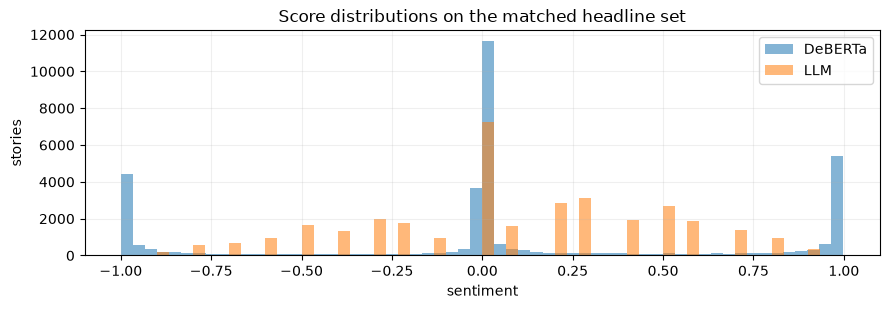

In [4]:
from IPython.display import Markdown
band = pd.cut(matched["llm_relevance"], [0, 0.3, 0.5, 0.7, 0.9, 1.0])
ladder = matched.groupby(band, observed=True).apply(
    lambda g: pd.Series({"stories": len(g),
                         "scorer agreement r": g["sent"].corr(g["llm_sent"])}))
display(Markdown("Method: Matched-story agreement is grouped by the LLM's relevance bands."))
display(ladder.round(3))
display(Markdown('Higher relevance accompanies stronger scorer agreement, not verified sentiment accuracy.'))

mix = (matched["llm_asset"].value_counts(normalize=True) * 100).round(1).rename("share %")
bias = (matched.assign(gap=matched["sent"] - matched["llm_sent"])
        .groupby("llm_asset")["gap"].agg(["mean", "count"]).round(3))
display(Markdown('Method: Matched headlines are grouped by LLM asset tag and mean DeBERTa-minus-LLM score.'))
display(mix.to_frame().join(bias).rename(columns={"mean": "DeBERTa - LLM", "count": "n"}))
display(Markdown('Asset attribution explains part of the aggregate scorer difference.'))

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.hist(matched["sent"], bins=60, alpha=0.55, label="DeBERTa", color="tab:blue")
ax.hist(matched["llm_sent"], bins=60, alpha=0.55, label="LLM", color="tab:orange")
ax.set(title="Score distributions on the matched headline set",
       xlabel="sentiment", ylabel="stories")
ax.legend()
fig.tight_layout()
fig.savefig(ARTIFACT_DIR / "02c_score_distributions.png", dpi=160, bbox_inches="tight")
plt.show()

## 4. Feature construction

Headline sentiment is a six-hour decayed weighted mean: DeBERTa uses keyword eligibility and confidence × log(1 + outlets), whereas LLM-full uses asset eligibility and relevance × impact.
LLM-matched uses the unweighted scalar control; shared inputs are story count, tone, macro releases and Fear & Greed.
Each sentiment arm also contains one direct-event pulse; LLM-full adds three structured channels, giving six versus nine sentiment columns.

In [5]:
from IPython.display import Markdown
arms = {}
for scorer, label in (("classic", "DeBERTa"), ("llm", "LLM")):
    for weighting in ("plain", "own"):
        arms[f"{label}-{weighting}"] = build_matched_sentiment_features(
            "btc", bars, scorer=scorer, weighting=weighting)

summary = pd.concat(
    {name: frame[MATCHED_SENTIMENT_FEATURES_BTC].agg(["mean", "std", "min", "max"]).T
     for name, frame in arms.items()},
    names=["Arm", "Feature"])
display(Markdown('Method: Per-bar feature distributions are computed with the same causal clock under plain and scorer-owned weighting.'))
display(summary.round(4))
display(Markdown('Weighting changes feature scale as well as direction.'))

headline = pd.DataFrame({
    name: {"std": f["sent_news_decay"].std(), "min": f["sent_news_decay"].min(),
           "max": f["sent_news_decay"].max(),
           "stories per 24h": f["sent_news_count_24h"].mean()}
    for name, f in arms.items()}).T
display(Markdown("Method: The headline column's range and story count are compared under each weighting rule."))
display(headline.round(3))
display(Markdown('A weighted mean separates directional scale from news volume.'))

# The three arms exactly as Notebook 02d receives them.
deployed = {
    "DeBERTa": pd.concat([arms["DeBERTa-own"],
                          build_direct_event_block("btc", bars, scorer="classic")],
                         axis=1),
    "LLM-matched": pd.concat([arms["LLM-plain"], build_direct_event_block(
        "btc", bars, scorer="llm", weighting="plain")], axis=1),
    "LLM-full": build_llm_full_features("btc", bars),
}
display(Markdown('Method: Column counts are taken from the exact frames passed to the model comparison.'))
display(pd.DataFrame({
    "sentiment columns": {k: v.shape[1] for k, v in deployed.items()},
    "direct-event channels": {k: sum(c.startswith("sent_direct") for c in v.columns)
                              for k, v in deployed.items()},
    "LLM structured channels": {k: sum(c.startswith("sent_llm") for c in v.columns)
                                for k, v in deployed.items()},
}))
display(Markdown('LLM-full has three additional structured channels, so this is a feature-layer comparison.'))

Method: Per-bar feature distributions are computed with the same causal clock under plain and scorer-owned weighting.

mean      std      min       max
Arm           Feature                                                 
DeBERTa-plain sent_news_decay       0.0166   0.0836  -0.9639    0.5632
              sent_news_count_24h  41.6118  24.2429   0.0000  186.0000
              sent_tone_decay      -0.2613   0.4170  -5.3761    2.9545
              sent_macro_decay      0.0043   0.0109   0.0000    0.2847
              sent_fng_change_7d   -0.4995  12.9253 -50.0000   49.0000
DeBERTa-own   sent_news_decay       0.0500   0.4338  -0.9979    0.9914
              sent_news_count_24h  25.3239  15.6617   0.0000  146.0000
              sent_tone_decay      -0.2613   0.4170  -5.3761    2.9545
              sent_macro_decay      0.0043   0.0109   0.0000    0.2847
              sent_fng_change_7d   -0.4995  12.9253 -50.0000   49.0000
LLM-plain     sent_news_decay       0.0367   0.0708  -0.8000    0.5606
              sent_news_count_24h  41.6118  24.2429   0.0000  186.0000
              sent_tone_decay      -0.2613   0.4170  -5.3761    2.9545
              sent_macro_decay      0.0043   0.0109   0.0000    0.2847
              sent_fng_change_7d   -0.4995  12.9253 -50.0000   49.0000
LLM-own       sent_news_decay       0.1229   0.2800  -0.7950    0.9073
              sent_news_count_24h  21.7775  14.0037   0.0000  137.0000
              sent_tone_decay      -0.2613   0.4170  -5.3761    2.9545
              sent_macro_decay      0.0043   0.0109   0.0000    0.2847
              sent_fng_change_7d   -0.4995  12.9253 -50.0000   49.0000

Weighting changes feature scale as well as direction.

Method: The headline column's range and story count are compared under each weighting rule.

,std,min,max,stories per 24h
DeBERTa-plain,0.084,-0.964,0.563,41.612
DeBERTa-own,0.434,-0.998,0.991,25.324
LLM-plain,0.071,-0.800,0.561,41.612
LLM-own,0.280,-0.795,0.907,21.777


A weighted mean separates directional scale from news volume.

Method: Column counts are taken from the exact frames passed to the model comparison.

,sentiment columns,direct-event channels,LLM structured channels
DeBERTa,6,1,0
LLM-matched,6,1,0
LLM-full,9,1,3


LLM-full has three additional structured channels, so this is a feature-layer comparison.

## 5. Direct events

Matched Fed releases and Truth Social posts form one signed, 48-hour-decayed sum, weighted only by the relevant scorer's own fields; the small event sample limits separate channel analysis.

In [6]:
from IPython.display import Markdown
direct_classic = pd.read_parquet(RAW / "scores_direct_events_btc.parquet")
direct_llm = pd.read_parquet(RAW / "scores_llm_direct_events_btc.parquet")
direct = direct_classic[[*keys, "sent"]].merge(
    direct_llm[[*keys, "llm_sent", "llm_relevance", "llm_impact", "llm_asset"]],
    on=keys, how="inner", validate="one_to_one").dropna(subset=["sent", "llm_sent"])
direct["seendate"] = pd.to_datetime(direct["seendate"], utc=True)
direct = first_seen_only(direct)
direct = direct.loc[direct["seendate"] < LOCKBOX]
direct["source"] = np.where(
    direct["url"].str.contains("federalreserve", case=False, na=False), "Fed", "Trump")

agree = float((np.sign(direct["sent"]) == np.sign(direct["llm_sent"])).mean())

block = {label: build_direct_event_block("btc", bars, scorer=scorer)
         for scorer, label in (("classic", "DeBERTa"), ("llm", "LLM"))}
shape = pd.DataFrame({
    "pulse std": {k: v["sent_direct_pulse"].std() for k, v in block.items()},
    "bars with a live pulse (|pulse| > 0.05)": {
        k: float((v["sent_direct_pulse"].abs() > 0.05).mean()) for k, v in block.items()},
    "share of live bars signed positive": {
        k: float((v["sent_direct_pulse"] > 0).mean()) for k, v in block.items()},
    "std of sent_news_decay": {
        "DeBERTa": arms["DeBERTa-own"]["sent_news_decay"].std(),
        "LLM": arms["LLM-own"]["sent_news_decay"].std()},
})
display(Markdown('Method: Direct-event pulse statistics use matched releases/posts and a 48-hour decay.'))
display(shape.round(4))
display(Markdown('The sparse, weakly agreeing event scores require cautious interpretation.'))

Method: Direct-event pulse statistics use matched releases/posts and a 48-hour decay.

,pulse std,bars with a live pulse (|pulse| > 0.05),share of live bars signed positive,std of sent_news_decay
DeBERTa,0.0700,0.0134,0.7938,0.4338
LLM,0.2808,0.1843,0.7489,0.2800


The sparse, weakly agreeing event scores require cautious interpretation.

## 6. Model-free diagnostics

Next-M15 correlations and ±24-hour event-aligned absolute returns are descriptive associations, not forecast tests or selection criteria; the event study also shows movement before crawler visibility.

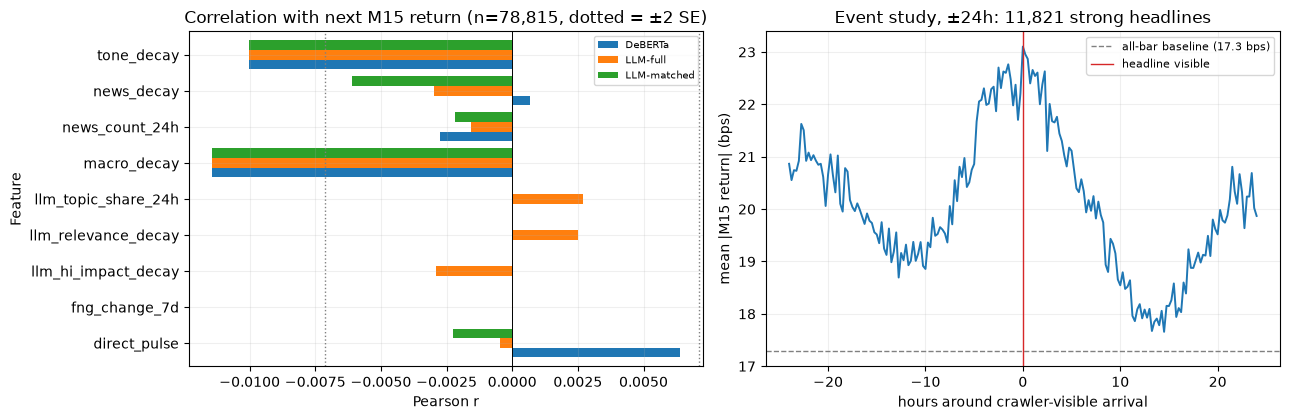

Method: Each sentiment feature is paired with the next-M15 return on the same available bars.

Arm,DeBERTa,LLM-full,LLM-matched
Feature,,,
direct_pulse,0.0064,-0.0005,-0.0022
fng_change_7d,0.0,0.0000,0.0
llm_hi_impact_decay,Not estimable,-0.0029,Not estimable
llm_relevance_decay,Not estimable,0.0025,Not estimable
llm_topic_share_24h,Not estimable,0.0027,Not estimable
macro_decay,-0.0114,-0.0114,-0.0114
news_count_24h,-0.0028,-0.0016,-0.0022
news_decay,0.0007,-0.0030,-0.0061
tone_decay,-0.01,-0.0100,-0.01


These small descriptive associations do not demonstrate trading value.

In [7]:
from IPython.display import Markdown
forward_return = price["close"].shift(-1).div(price["close"]).sub(1.0).rename("next")
corr_rows = []
for name, frame in deployed.items():
    joined = frame.join(forward_return)
    for feature in frame.columns:
        corr_rows.append({"Arm": name, "Feature": feature.replace("sent_", ""),
                          "r": joined[feature].corr(joined["next"])})
corr = pd.DataFrame(corr_rows)
n_obs = int(forward_return.notna().sum())
se = 1.0 / np.sqrt(n_obs)

WINDOW = 96                                    # 24 hours of M15 bars
strong = matched.loc[matched[["sent", "llm_sent"]].abs().max(axis=1) >= 0.9]
log_return = np.log(price["close"]).diff()
positions = price.index.searchsorted(
    pd.DatetimeIndex(strong["seendate"]).to_numpy(), side="right") - 1
positions = positions[(positions >= WINDOW) & (positions < len(price) - WINDOW - 1)]
matrix = np.stack([log_return.to_numpy()[p - WINDOW:p + WINDOW + 1] for p in positions])
offsets = np.arange(-WINDOW, WINDOW + 1)
move = np.nanmean(np.abs(matrix), axis=0) * 1e4
baseline = float(np.nanmean(np.abs(log_return)) * 1e4)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
corr.pivot(index="Feature", columns="Arm", values="r").plot(kind="barh", ax=axes[0],
                                                            width=0.8)
axes[0].axvline(0, color="black", lw=0.7)
for edge in (-2 * se, 2 * se):
    axes[0].axvline(edge, color="grey", ls=":", lw=1)
axes[0].set(title=f"Correlation with next M15 return (n={n_obs:,}, dotted = ±2 SE)",
            xlabel="Pearson r")
axes[0].legend(fontsize=7)

axes[1].plot(offsets / 4, move, lw=1.4, color="tab:blue")
axes[1].axhline(baseline, color="grey", ls="--", lw=1,
                label=f"all-bar baseline ({baseline:.1f} bps)")
axes[1].axvline(0, color="tab:red", lw=1, label="headline visible")
axes[1].set(title=f"Event study, ±24h: {len(positions):,} strong headlines",
            xlabel="hours around crawler-visible arrival",
            ylabel="mean |M15 return| (bps)")
axes[1].legend(fontsize=8)
fig.tight_layout()
fig.savefig(ARTIFACT_DIR / "02c_sentiment_diagnostics.png", dpi=160, bbox_inches="tight")
plt.show()

excess = move - baseline
peak = float(excess[WINDOW])
before = excess[:WINDOW]
onset = (offsets[np.argmax(before > 0.5 * peak)] / 4
         if bool((before > 0.5 * peak).any()) else float("nan"))
display(Markdown('Method: Each sentiment feature is paired with the next-M15 return on the same available bars.'))
display((corr.pivot(index="Feature", columns="Arm", values="r").round(4)).fillna('Not estimable'))
display(Markdown('These small descriptive associations do not demonstrate trading value.'))

## Conclusion

Scorers differ materially, but correlations and delayed headline visibility do not establish tradable value; Notebook 02d tests the four matched arms with unchanged market predictors and execution.